# Sampel 2, Motif Ranting

In [13]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import skan
from utils import *

Text(0.5, 1.0, 'Binarized Sample')

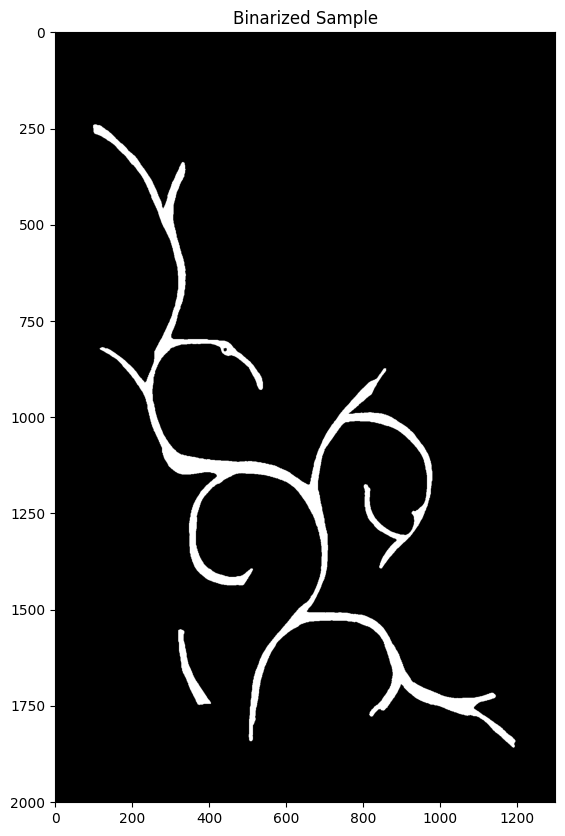

In [15]:
branch = cv2.imread("sampel-2_motif-ranting.png")
branch_binary = binarize(branch).astype(np.uint8)
branch_binary = branch_binary[500:2501, 200:1501]

height, width = branch_binary.shape

plt.figure(figsize=(10,10))
plt.imshow(branch_binary, cmap='gray')
plt.title("Binarized Sample")

In [16]:
branch_contours = extractContours(branch_binary)

branch_contour_map = createContourMap(branch_binary.shape, branch_contours)

27

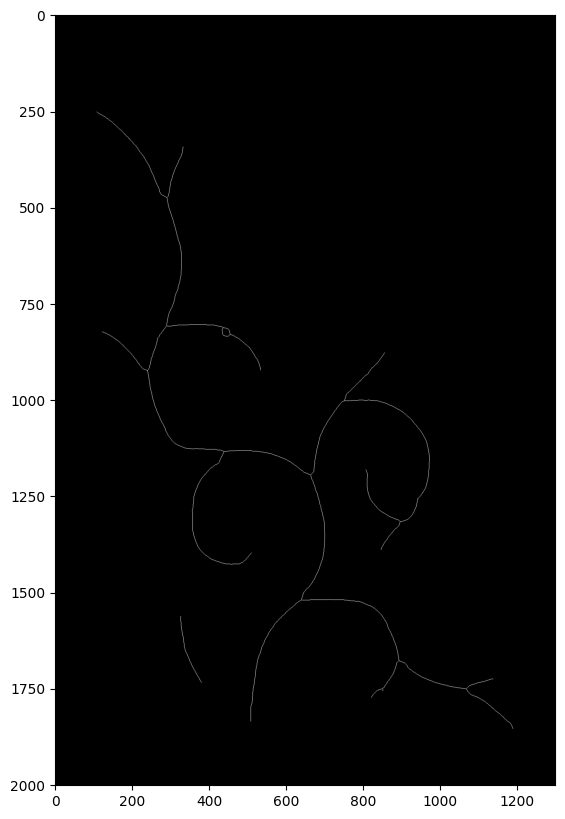

In [17]:
branch_skeleton_image, branch_skan = skeletonize(branch_binary)

plt.figure(figsize=(10,10))
plt.imshow(branch_skeleton_image, cmap='gray')

branch_skan.n_paths

## Ketebalan Cabang

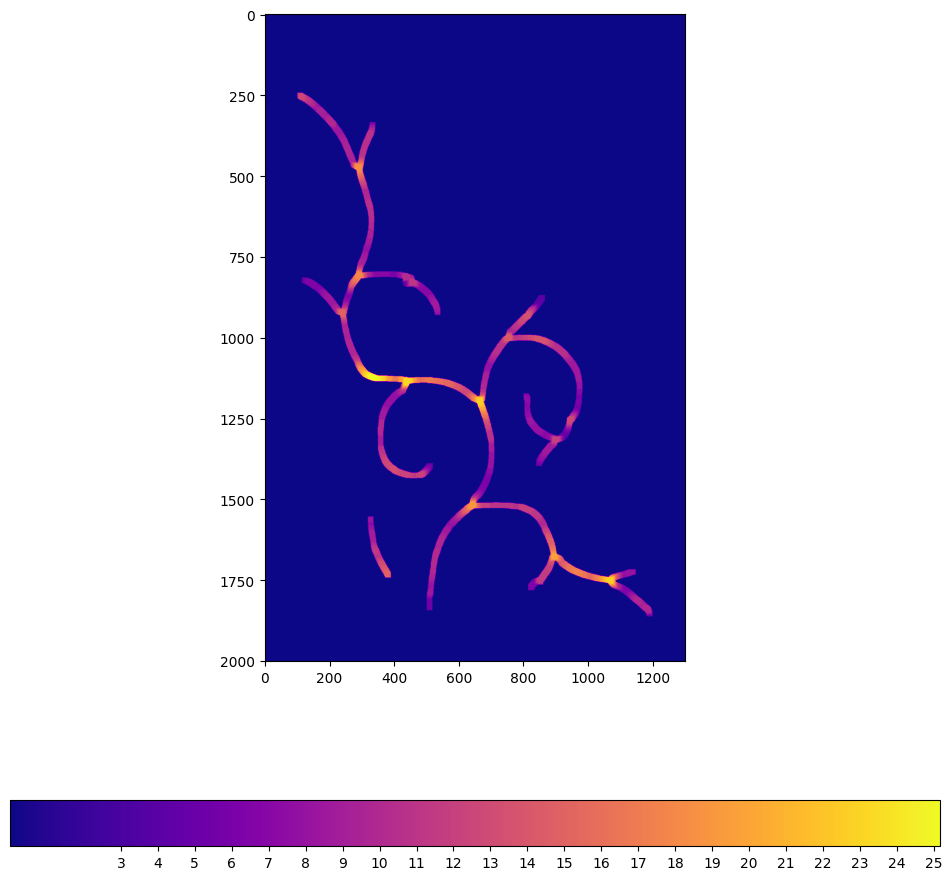

In [18]:
branch_thickness_map = mapThickness(branch_skeleton_image, branch_binary, 5)
branch_thickness = branch_thickness_map.flatten()
branch_thickness = branch_thickness[branch_thickness > 0]

plt.figure(figsize=(12, 12))
plt.imshow(cv2.dilate(branch_thickness_map, np.ones((3, 3), np.uint8), iterations=8), cmap='plasma')
colorbar = plt.colorbar(orientation='horizontal')
colorbar.set_ticks(range(int(min(branch_thickness)), int(max(branch_thickness)) + 1, 1))

DATA SUMMARY of [Branch Thickness]:
Num     : 4878
Mean    : 10.6635
SD      : 3.8094
SD rel  : 35.72%
Median  : 9.7876
MAD     : 1.9907
MAD rel : 20.34%
Min     : 3.5969
Max     : 25.1659



{'num': 4878,
 'mean': 10.663535,
 'sd': 3.809441,
 'median': 9.7876,
 'mad': 1.9906998,
 'min': 3.5969,
 'max': 25.165895}

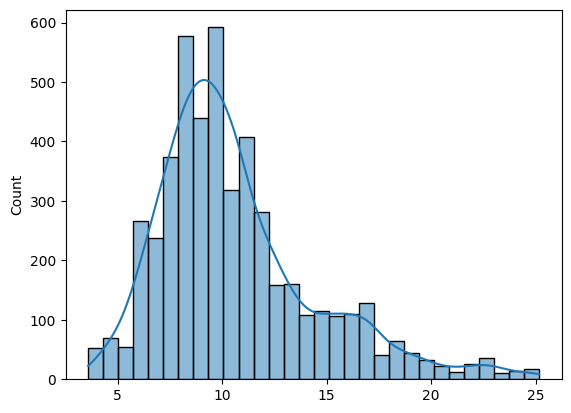

In [19]:
sns.histplot(branch_thickness, kde=True, bins=30)
summarizeData(branch_thickness, "Branch Thickness")

## Orientasi Cabang

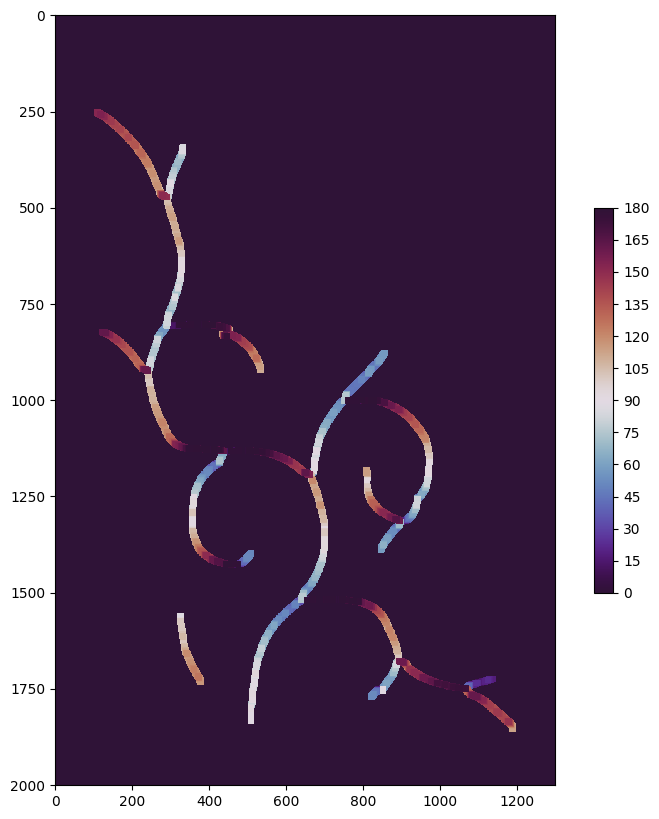

In [20]:
branch_orientation_map = np.rad2deg(mapBranchOrientation(branch_skeleton_image, branch_skan, 15))
branch_orientation_map_test = (branch_orientation_map + 0)
branch_orientation_map_test[np.isnan(branch_orientation_map_test)] = 0
branch_orientation_map_test = cv2.dilate(branch_orientation_map_test, np.ones((3, 3), np.uint8), iterations=8)

plt.figure(figsize=(10, 10))
plt.imshow(branch_orientation_map_test, cmap='twilight_shifted', vmin=0, vmax=180, interpolation='nearest')
colorbar = plt.colorbar(shrink=0.5)

colorbar.set_ticks(range(0, 181, 15))

Text(0.5, 1.0, 'Branch Orientations')

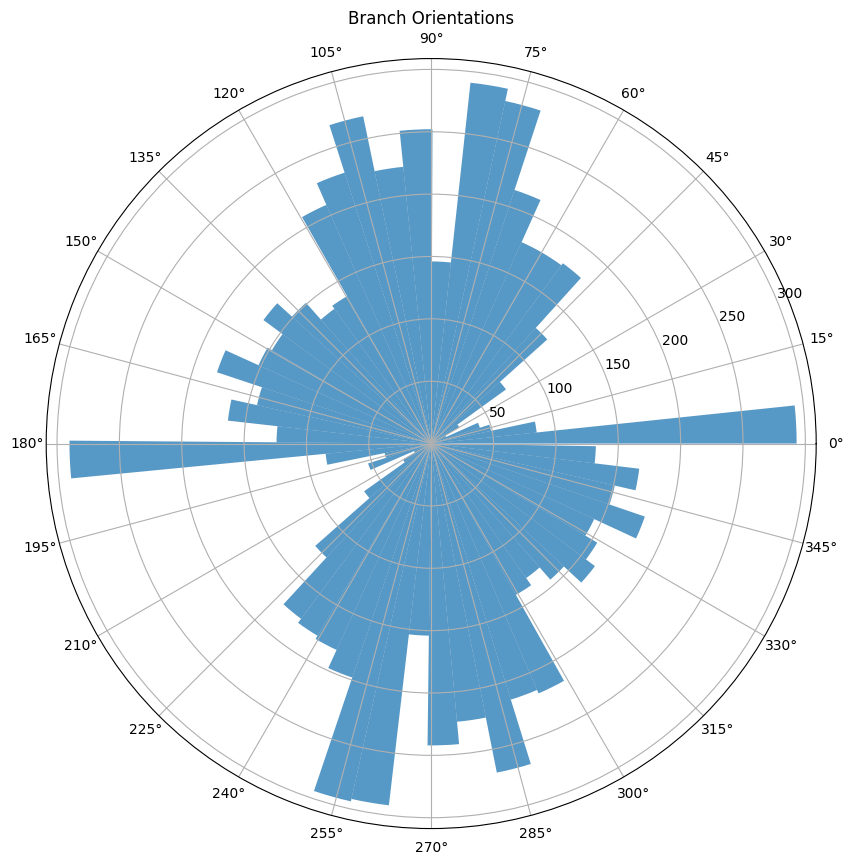

In [21]:
branch_orientations = branch_orientation_map[~np.isnan(branch_orientation_map)]
branch_orientations_repeated = np.concatenate((branch_orientations, branch_orientations + 180))

plt.figure(figsize=(10,10))
# plt.xticks(range(0, 361, 15))
ax = plt.axes(projection="polar")
ax.set_xticks(np.arange(0, np.pi*2, np.pi/12))
sns.histplot(branch_orientations_repeated / 180 * np.pi, ax=ax, bins=60)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Branch Orientations")

## Kelengkungan Cabang (Sudut Belok)

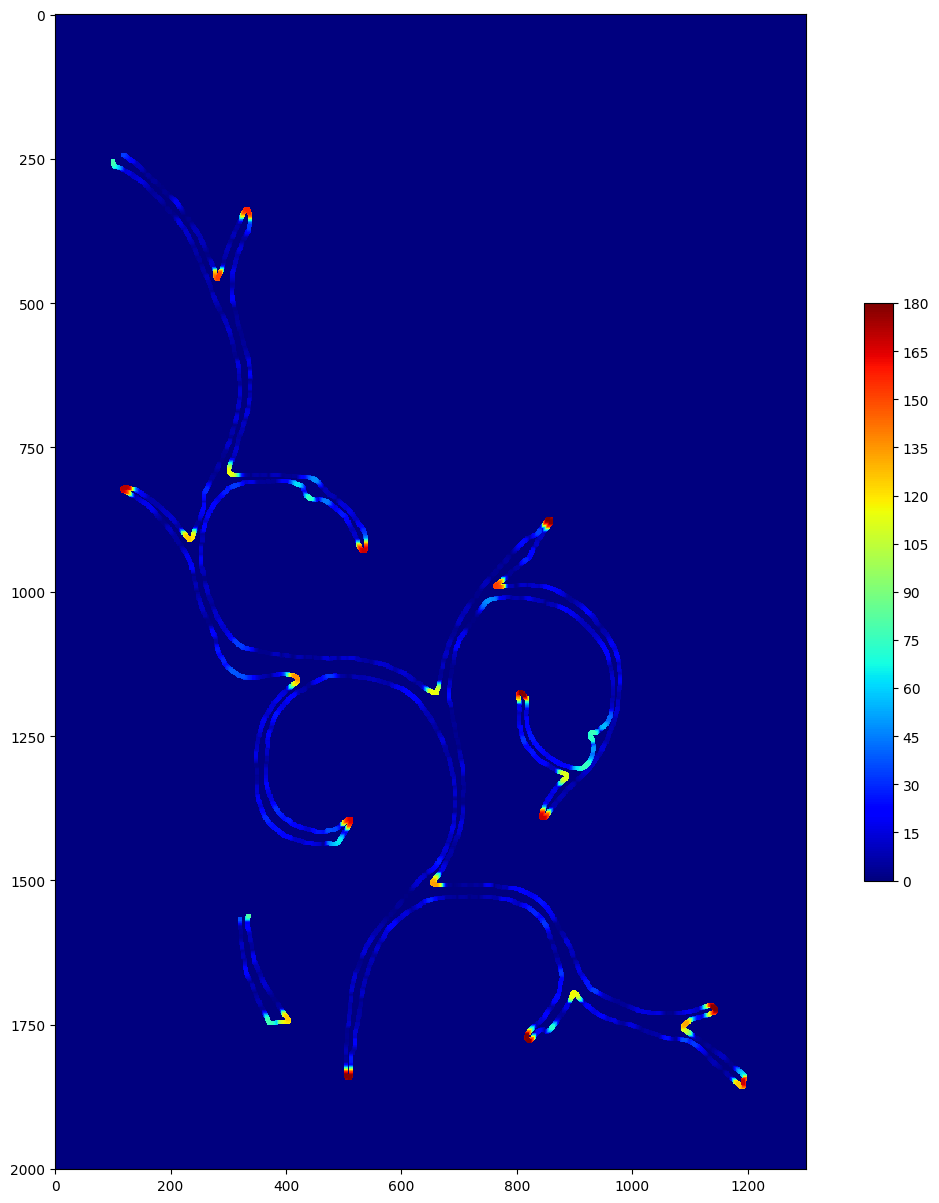

In [22]:
branch_contour_skeleton_image, branch_contour_skan = skeletonize(branch_contour_map)

branch_contour_curvature_map = mapBranchCurvature(branch_contour_skeleton_image, branch_contour_skan, 31)

branch_contour_curvature_map_test = branch_contour_curvature_map * 1
branch_contour_curvature_map_test[np.isnan(branch_contour_curvature_map_test)] = 0
branch_contour_curvature_map_test = cv2.dilate(branch_contour_curvature_map_test, np.ones((3, 3), np.uint8), iterations=3)

plt.figure(figsize=(15, 15))
plt.imshow(branch_contour_curvature_map_test / np.pi * 180, cmap='jet', vmin=0, vmax=180, interpolation='nearest')
colorbar = plt.colorbar(shrink=0.5)
colorbar.set_ticks(range(0, 181, 15))

<Axes: ylabel='Count'>

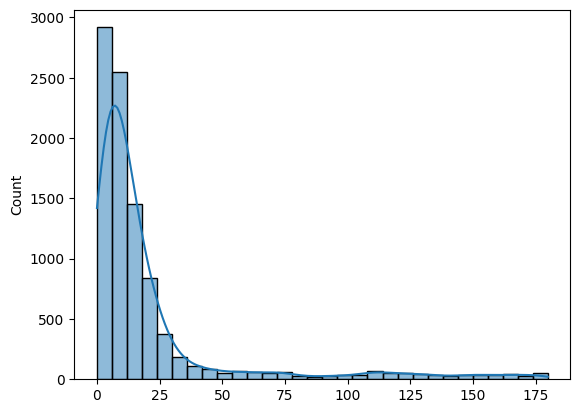

In [23]:
sns.histplot(branch_contour_curvature_map[~np.isnan(branch_contour_curvature_map)] / np.pi * 180, kde=True, bins=30)